In [6]:
!pip install scikit-learn

In [7]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn import datasets
import seaborn as sns
import warnings 
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [8]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
df.head()#printing first 5 rows


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [9]:
df.tail()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [10]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [11]:
df["diabetes"].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

In [13]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [14]:
df['gender']=df['gender'].replace(to_replace=['Female', 'Male',"Other"], value=[0, 1, 2])
df['smoking_history']=df['smoking_history'].replace(to_replace=['never', 'No Info',"current","former","ever","not current" ], value=[0, 1, 2, 3, 4, 5])

C:\Users\Admin\AppData\Local\Temp\ipykernel_18796\469082970.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender']=df['gender'].replace(to_replace=['Female', 'Male',"Other"], value=[0, 1, 2])
C:\Users\Admin\AppData\Local\Temp\ipykernel_18796\469082970.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoking_history']=df['smoking_history'].replace(to_replace=['never', 'No Info',"current","former","ever","not current" ], value=[0, 1, 2, 3, 4, 5])


In [15]:
X=df[['gender','age','hypertension','heart_disease','smoking_history','bmi','HbA1c_level','blood_glucose_level']]
y=df['diabetes']

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [17]:
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
y_pred = dummy_clf.predict(X_test)
accuracy = dummy_clf.score(X_test, y_test)
print("Accuracy:", accuracy * 100, "%")
print(classification_report(y_test, dummy_clf.predict(X_test)))


Accuracy: 91.53666666666666 %
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     27461
           1       0.00      0.00      0.00      2539

    accuracy                           0.92     30000
   macro avg       0.46      0.50      0.48     30000
weighted avg       0.84      0.92      0.87     30000



F:\Polygence\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
F:\Polygence\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
F:\Polygence\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
model1 = LogisticRegression()
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100 )

Accuracy: 95.87


F:\Polygence\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

L1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C=0.1)

L1.fit(X_train, y_train)

y_pred = L1.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 96.10%


Feature Importance (Coefficients):
               Feature  Coefficient
3        heart_disease     2.113214
6          HbA1c_level     1.973720
2         hypertension     0.557285
0               gender    -0.095057
4      smoking_history     0.084237
5                  bmi     0.041586
1                  age     0.040443
7  blood_glucose_level     0.031085


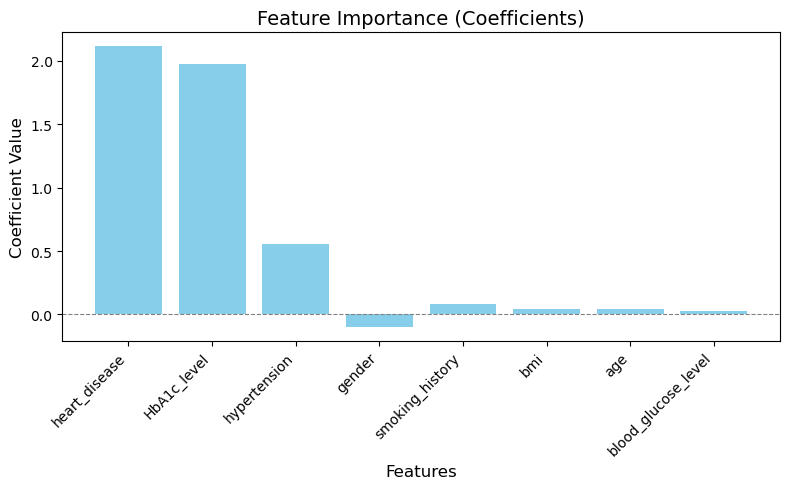

In [20]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# Assuming L1 is your trained LogisticRegression model
start_time = time.time()

# Extract coefficients and corresponding feature names
coefficients = model1.coef_[0]  # Get the coefficients (ensure it's a 1D array)
feature_names = X_train.columns  # Assuming X_train is a DataFrame

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)  # Sort by absolute value

print("Feature Importance (Coefficients):")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 5))  # Set figure size
plt.bar(feature_importance['Feature'], feature_importance['Coefficient'], color='skyblue')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')  # Add a horizontal line at 0
plt.title("Feature Importance (Coefficients)", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Coefficient Value", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()


Feature Importance (Coefficients):
               Feature  Coefficient
6          HbA1c_level     2.177032
2         hypertension     0.782960
3        heart_disease     0.698673
0               gender     0.201468
5                  bmi     0.086716
1                  age     0.043859
4      smoking_history     0.033628
7  blood_glucose_level     0.032270


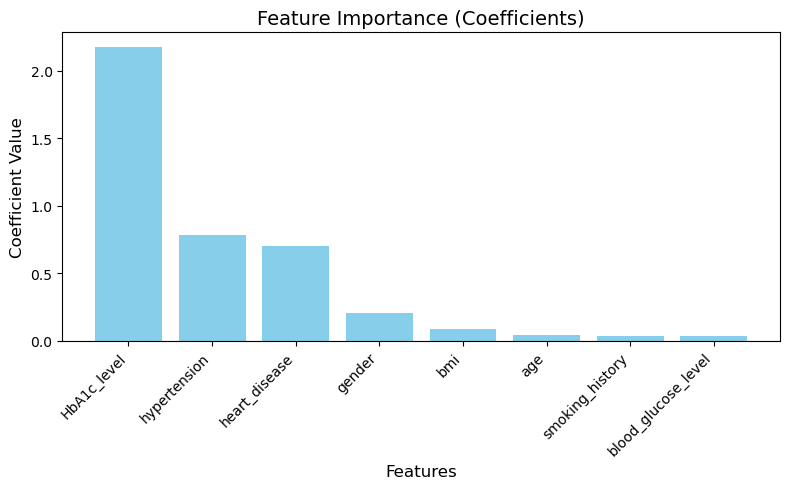

In [21]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# Assuming L1 is your trained LogisticRegression model
start_time = time.time()

# Extract coefficients and corresponding feature names
coefficients = L1.coef_[0]  # Get the coefficients (ensure it's a 1D array)
feature_names = X_train.columns  # Assuming X_train is a DataFrame

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)  # Sort by absolute value

print("Feature Importance (Coefficients):")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 5))  # Set figure size
plt.bar(feature_importance['Feature'], feature_importance['Coefficient'], color='skyblue')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')  # Add a horizontal line at 0
plt.title("Feature Importance (Coefficients)", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Coefficient Value", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()

In [22]:
clf=RandomForestClassifier(n_estimators=100)
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

In [23]:
print("accuracy:",metrics.accuracy_score(y_test,y_pred) * 100,"%" )

accuracy: 97.11999999999999 %


In [24]:
print("Hyperparameters of the trained model:")
print(clf.get_params())

Hyperparameters of the trained model:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


Elapsed time to compute the importances: 0.015 seconds


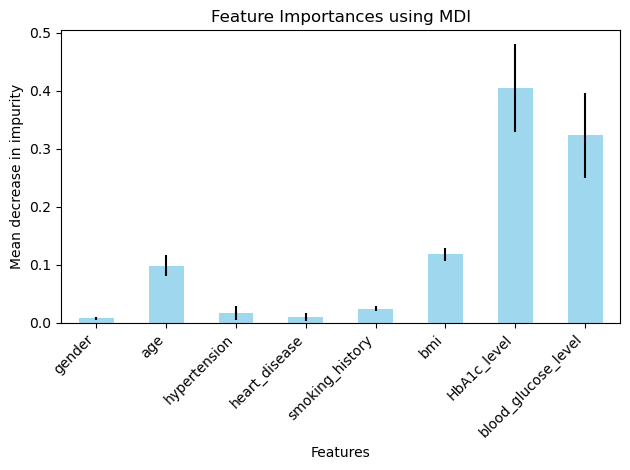

In [25]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming clf is your trained model and X_train is your training data as a DataFrame
start_time = time.time()

# Calculate feature importances
importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

# Replace generic feature names with actual feature names
feature_names = X_train.columns  # Ensure X_train is a DataFrame

# Create a DataFrame for the feature importances
forest_importances = pd.Series(importances, index=feature_names)

# Plot feature importances
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax, color="skyblue", alpha=0.8)
ax.set_title("Feature Importances using MDI")
ax.set_xlabel("Features")  # Set x-axis label
ax.set_ylabel("Mean decrease in impurity")
plt.xticks(rotation=45, ha='right')  # Rotate feature names for better readability
plt.tight_layout()
plt.show()

Elapsed time to compute the importances: 12.183 seconds


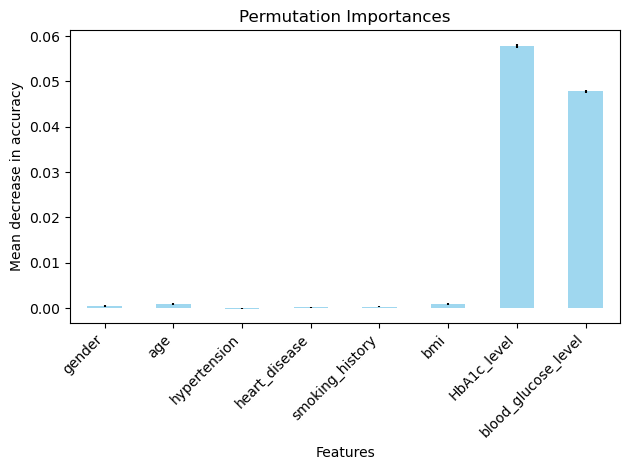

In [26]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import time

# Start timing
start_time = time.time()

# Calculate permutation importance
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)

elapsed_time = time.time() - start_time
print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

# Replace generic feature names with actual column names
feature_names = X_test.columns  # Ensure X_test is a DataFrame

# Create a Series for the permutation importances
forest_importances = pd.Series(result.importances_mean, index=feature_names)

# Plot permutation importances
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax, color="skyblue", alpha=0.8)
ax.set_title("Permutation Importances")
ax.set_xlabel("Features")
ax.set_ylabel("Mean decrease in accuracy")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

<Axes: >

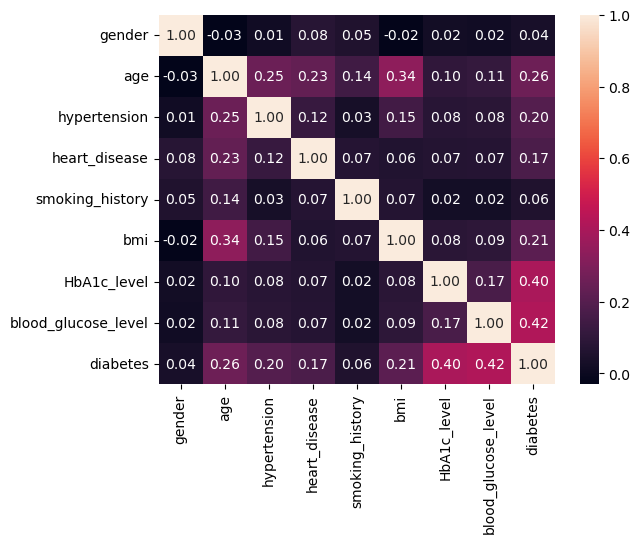

In [27]:
corr=df.corr()
sns.heatmap(corr,cbar=True,annot=True,fmt='.2f' )

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
cm=confusion_matrix(y_pred, y_test)
print("confusion matrix :\n",cm)
print("\n Classification Report \n",classification_report(y_pred, y_test))

confusion matrix :
 [[27382   785]
 [   79  1754]]

 Classification Report 
               precision    recall  f1-score   support

           0       1.00      0.97      0.98     28167
           1       0.69      0.96      0.80      1833

    accuracy                           0.97     30000
   macro avg       0.84      0.96      0.89     30000
weighted avg       0.98      0.97      0.97     30000



In [29]:
from sklearn.model_selection import KFold, cross_val_score
k_folds = KFold(n_splits = 5)

scores = cross_val_score(L1, X, y, cv = k_folds)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores:  [0.96035 0.9597  0.95825 0.96205 0.96015]
Average CV Score:  0.9601000000000001
Number of CV Scores used in Average:  5


In [30]:
from sklearn.model_selection import KFold, cross_val_score
k_folds = KFold(n_splits = 5)

scores = cross_val_score(model1, X, y, cv = k_folds)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

F:\Polygence\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
F:\Polygence\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

Cross Validation Scores:  [0.952  0.9548 0.9511 0.9556 0.9514]
Average CV Score:  0.9529799999999999
Number of CV Scores used in Average:  5


F:\Polygence\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
from sklearn.model_selection import KFold, cross_val_score
k_folds = KFold(n_splits = 5)

scores = cross_val_score(clf, X, y, cv = k_folds)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores:  [0.9697  0.9704  0.9671  0.97175 0.97095]
Average CV Score:  0.96998
Number of CV Scores used in Average:  5


C:\Users\Admin\AppData\Local\Temp\ipykernel_18796\1973099156.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Model", y="Accuracy", data=df, jitter=True, size=8, palette="Set2")


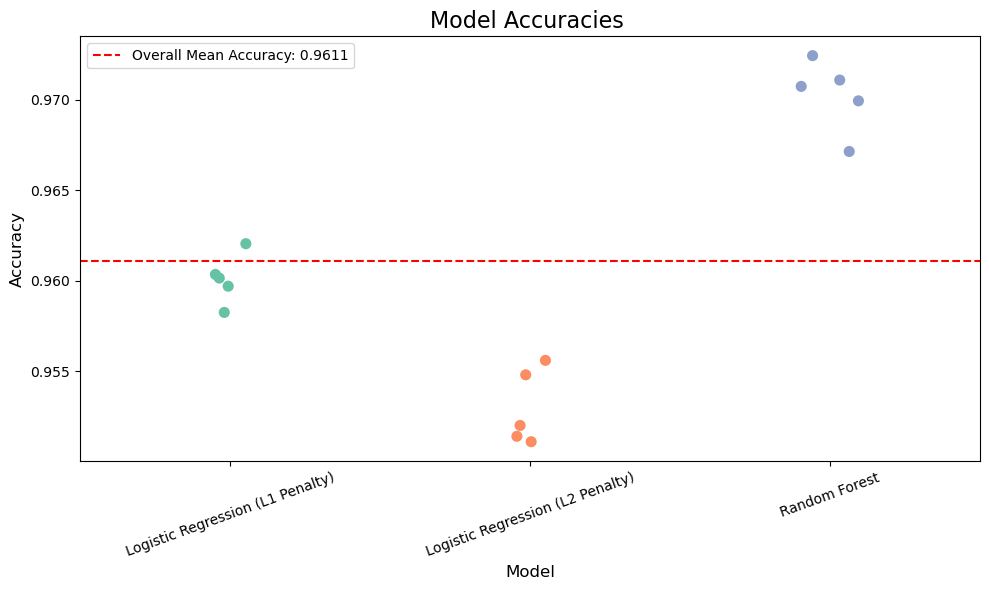

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Accuracies provided for each model
l1_accuracies = [0.96035, 0.9597, 0.95825, 0.96205, 0.96015]
l2_accuracies = [0.952, 0.9548, 0.9511, 0.9556, 0.9514]
rf_accuracies = [0.96995, 0.97075, 0.96715, 0.97245, 0.9711]

# Combine data into a DataFrame
data = {
    "Model": ["Logistic Regression (L1 Penalty)"] * len(l1_accuracies) +
             ["Logistic Regression (L2 Penalty)"] * len(l2_accuracies) +
             ["Random Forest"] * len(rf_accuracies),
    "Accuracy": l1_accuracies + l2_accuracies + rf_accuracies
}

df = pd.DataFrame(data)

# Calculate the mean accuracy for all three models
mean_accuracy = df["Accuracy"].mean()

# Create the strip plot
plt.figure(figsize=(10, 6))
sns.stripplot(x="Model", y="Accuracy", data=df, jitter=True, size=8, palette="Set2")

# Add the horizontal line for the mean accuracy
plt.axhline(mean_accuracy, color="red", linestyle="--", linewidth=1.5, label=f"Overall Mean Accuracy: {mean_accuracy:.4f}")

# Customize the plot
plt.title("Model Accuracies ", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=20, fontsize=10)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()




In [33]:
!pip install pingouin --quiet

import numpy as np
import pingouin as pg
from sklearn.metrics import confusion_matrix

# Get predictions for both models
log_preds = model1.predict(X_test)  # Logistic Regression predictions
rf_preds = clf.predict(X_test)      # Random Forest predictions

# Constructing the contingency table for McNemar’s Test
b = np.sum((log_preds == 1) & (rf_preds == 0))  # Logistic correct, RF incorrect
c = np.sum((log_preds == 0) & (rf_preds == 1))  # Logistic incorrect, RF correct

# Create 2x2 contingency table
table = np.array([[0, b], [c, 0]])

# Print the contingency table
print("Contingency Table:\n", table)

# Run McNemar's Test
result = pg.chi2_mcnemar(table)
print("\nMcNemar's Test Result:\n", result)

# Interpretation
p_value = result.loc['chi2', 'pval']
if p_value < 0.05:
    print("\nSignificant difference between models (p-value < 0.05).")
else:
    print("\nNo significant difference between models (p-value ≥ 0.05).")


Contingency Table:
 [[  0 318]
 [355   0]]


TypeError: chi2_mcnemar() missing 2 required positional arguments: 'x' and 'y'

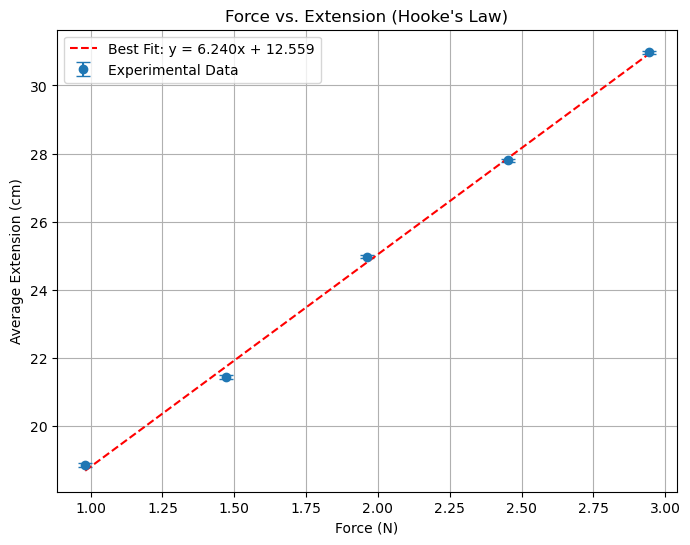

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Given Data
force = np.array([0.981, 1.472, 1.962, 2.453, 2.943])  # Force in Newtons
extension = np.array([18.85, 21.43, 24.97, 27.80, 30.97])  # Average Extension in cm
uncertainty = np.full_like(extension, 0.05)  # Uncertainty in Extension (cm)

# Plotting the Graph
plt.figure(figsize=(8, 6))
plt.errorbar(force, extension, yerr=uncertainty, fmt='o', capsize=5, capthick=1, label="Experimental Data")

# Best-Fit Line (Linear Regression)
m, b = np.polyfit(force, extension, 1)  # Linear fit (slope & intercept)
best_fit_line = m * force + b
plt.plot(force, best_fit_line, '--r', label=f"Best Fit: y = {m:.3f}x + {b:.3f}")

# Graph Formatting
plt.xlabel("Force (N)")
plt.ylabel("Average Extension (cm)")
plt.title("Force vs. Extension (Hooke's Law)")
plt.legend()
plt.grid(True)

# Show Graph
plt.show()
